# Curve fitting and calibration with `scipy.optimize`

Non-linear least squares and maximum likelihood on the hourly power data: fitting the
temperature–demand curve, a supply curve, a load-profile shape and an AR(1) model, and
the things that go wrong (starting values, identifiability, scaling, correlated errors).

**What's in here**
- `curve_fit` vs `least_squares`: same problem, two APIs
- Heating / cooling degree model with unknown breakpoints; local minima; bounds
- Variable projection: fit hour dummies linearly, breakpoints non-linearly
- Identifiability: profile the cost over a parameter and see when it is flat
- Standard errors from the Jacobian and why they lie under autocorrelation
- Robust losses (`soft_l1`, `huber`) when spikes are present
- Supply curve: exponential vs linear, and inverting it with `brentq`
- Two-Gaussian daily load shape
- Maximum likelihood with `minimize`: Nelder-Mead vs L-BFGS-B, `res.success`
- Scaling parameters and inputs (`x_scale`, normalising) — the overflow demo
- In-sample fit on 2022, out-of-sample check on 2023

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
df["hour"] = df["time"].dt.hour
df["is_weekend"] = (df["time"].dt.dayofweek >= 5).astype(int)
df["year"] = df["time"].dt.year
df["t"] = np.arange(len(df)) / len(df)          # 0..1 time index for a trend term
df.head(3)

,time,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh,hour,is_weekend,year,t
0,2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83,0,1,2022,0.000000
1,2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21,1,1,2022,0.000057
2,2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71,2,1,2022,0.000114


## 1. The problem: demand as a function of temperature

Below ~15 °C demand rises as it gets colder (heating); above ~22 °C it rises with heat
(cooling). The model is

`consumption = a + b · max(T_h − T, 0) + c · max(T − T_c, 0)`

with **five unknowns**: level `a`, slopes `b`, `c` and the two breakpoints `T_h`, `T_c`.
The breakpoints make it non-linear. First look at the raw relationship, then at the
relationship after removing hour-of-day and weekend effects (which otherwise dominate).

In [2]:
# hour-of-day and weekend explain a lot; remove their group means before looking at temperature
df["resid_hw"] = df["consumption_mwh"] - df.groupby(["hour", "is_weekend"])["consumption_mwh"].transform("mean")

bins = pd.cut(df["temp_c"], bins=np.arange(-8, 30, 2))
prof = df.groupby(bins, observed=True).agg(n=("temp_c", "size"),
                                           raw=("consumption_mwh", "mean"),
                                           hw_adjusted=("resid_hw", "mean")).round(0)
prof

,n,raw,hw_adjusted
temp_c,,,
"(-8, -6]",7,29649.0,4997.0
"(-6, -4]",107,30291.0,4837.0
"(-4, -2]",302,30192.0,4096.0
"(-2, 0]",728,29975.0,3331.0
"(0, 2]",1274,30682.0,2728.0
"(2, 4]",1571,31127.0,2161.0
"(4, 6]",1684,30971.0,1513.0
"(6, 8]",1612,30808.0,875.0
"(8, 10]",1515,29604.0,111.0


**Interview check:** "How many hours are above 22 °C?" Only a few hundred out of 17,520.
Any parameter that is identified only by those hours will be poorly estimated. Look at
the `n` column before you fit anything.

In [3]:
print("hours above 22C:", (df.temp_c > 22).sum(), " above 20C:", (df.temp_c > 20).sum(),
      " below 15C:", (df.temp_c < 15).sum(), " of", len(df))

hours above 22C: 401  above 20C: 1072  below 15C: 12864  of 17520


## 2. `curve_fit`: model function first, data second

`curve_fit(f, xdata, ydata, p0, bounds)` returns the parameter vector and its covariance.
`f` takes the independent variable first, then the parameters as separate arguments.
Always give `p0`: the default (all ones) is meaningless for breakpoints.

In [4]:
def hdd_cdd(T, a, b, c, Th, Tc):
    return a + b * np.clip(Th - T, 0, None) + c * np.clip(T - Tc, 0, None)

T = df["temp_c"].values
y = df["resid_hw"].values

p0 = [0, 300, 100, 14, 21]
popt, pcov = optimize.curve_fit(hdd_cdd, T, y, p0=p0)
se = np.sqrt(np.diag(pcov))
pd.DataFrame({"estimate": popt, "std_err": se}, index=["a", "b_heat", "c_cool", "T_heat", "T_cool"]).round(2)

,estimate,std_err
a,-2283.12,127.30
b_heat,360.87,1.65
c_cool,88.38,5.99
T_heat,15.24,0.35
T_cool,15.18,1.41


**Pitfall:** the fit converged, `curve_fit` raised nothing, and yet `T_cool` collapsed
onto `T_heat` (≈15 °C). With both breakpoints equal the model is just two straight lines
meeting at 15 °C — a *different* model that happens to fit nearly as well. Convergence is
not correctness. Check the estimates against what you know before using them.

In [5]:
# same fit with bounds that keep the breakpoints apart: T_heat in [5, 18], T_cool in [18, 30]
lb = [-1e5,    0,    0,  5, 18]
ub = [ 1e5, 1e3, 1e3, 18, 30]
popt_b, pcov_b = optimize.curve_fit(hdd_cdd, T, y, p0=p0, bounds=(lb, ub))
pd.DataFrame({"unbounded": popt, "bounded": popt_b, "true": [np.nan, 380, 120, 15, 22]},
             index=["a", "b_heat", "c_cool", "T_heat", "T_cool"]).round(2)

,unbounded,bounded,true
a,-2283.12,-2136.64,NaN
b_heat,360.87,360.44,380.0
c_cool,88.38,113.93,120.0
T_heat,15.24,14.85,15.0
T_cool,15.18,18.00,22.0


`T_cool` now sits **exactly on the lower bound (18)**. A parameter on a bound is a
warning sign: the optimiser wanted to go further, or the data do not care.

## 3. `least_squares`: the same problem with a residual function

`least_squares(fun, x0, bounds, loss, x_scale)` minimises `0.5 · Σ fun(x)²`. `fun`
returns the residual vector. It gives you the Jacobian, robust losses and better
diagnostics (`status`, `message`, `nfev`). `curve_fit` is a thin wrapper around it.

In [6]:
def residuals(theta, T, y):
    return hdd_cdd(T, *theta) - y

res = optimize.least_squares(residuals, x0=p0, bounds=(lb, ub), args=(T, y))
print("status:", res.status, "|", res.message)
print("nfev:", res.nfev, " cost:", f"{res.cost:.4g}")
print("x:", res.x.round(2))
print("params on a bound:", np.isclose(res.x, lb) | np.isclose(res.x, ub))

status: 2 | `ftol` termination condition is satisfied.
nfev: 7  cost: 7.694e+09
x: [-2136.64   360.44   113.93    14.85    18.  ]
params on a bound: [False False False False  True]


### Starting values decide which minimum you find

Piecewise models have kinks, so the cost surface has several basins. Try a few starting
points and look at the final cost, not only whether it "converged".

In [7]:
starts = {
    "reasonable":  [0, 300, 100, 14, 21],
    "cold/hot":    [0, 100, 100, 10, 25],
    "zero slopes": [0,   0,   0,  5, 28],
    "kinks close": [0, 500, 500, 18, 19],
}
rows = []
for name, x0 in starts.items():
    r = optimize.least_squares(residuals, x0=x0, args=(T, y))       # unbounded on purpose
    rows.append([name, *r.x.round(1), r.cost / 1e9, r.status])
pd.DataFrame(rows, columns=["x0", "a", "b_heat", "c_cool", "T_heat", "T_cool", "cost/1e9", "status"])

,x0,a,b_heat,c_cool,T_heat,T_cool,cost/1e9,status
0,reasonable,-2023.2,359.6,99.9,14.6,35.7,7.786569,2
1,cold/hot,-2023.2,359.6,-747.1,14.6,35.1,7.786569,2
2,zero slopes,-2023.3,359.6,0.0,14.6,28.0,7.786569,2
3,kinks close,-2283.6,360.9,88.5,15.2,15.2,7.676962,2


Four starting points, all with `status ≥ 1` ("converged"), two different answers. Three
runs pushed `T_cool` above the warmest hour in the data (27.7 °C), so the cooling term is
never active and `c_cool` is arbitrary — 99.9, −747 and 0 all give the *same* cost. The
fourth found the "two lines meeting at 15 °C" solution with a lower cost. That tells you
something real: **in this data, the cooling breakpoint is barely identified**.

## 4. Variable projection: linear parameters linearly, non-linear ones non-linearly

Removing hour/weekend means *before* fitting biases the temperature slope (temperature
has its own diurnal cycle, so the hour means absorb part of the heating effect: we got
≈360 rather than 380). The clean way: for fixed breakpoints, the model is **linear** in
hour dummies, weekend, trend and the two slopes → solve with `lstsq`. Then optimise only
the two breakpoints in the outer loop. Two non-linear parameters instead of 30.

In [8]:
H = pd.get_dummies(df["hour"]).to_numpy(dtype=float)          # 24 hour dummies (no intercept needed)
wk = df["is_weekend"].to_numpy(dtype=float)
t = df["t"].to_numpy()
y_full = df["consumption_mwh"].to_numpy()

def design(Th, Tc):
    return np.column_stack([H, wk, t, np.clip(Th - T, 0, None), np.clip(T - Tc, 0, None)])

def sse(bp):
    X = design(*bp)
    beta, *_ = np.linalg.lstsq(X, y_full, rcond=None)
    r = y_full - X @ beta
    return r @ r

res_vp = optimize.minimize(sse, x0=[14, 21], method="Nelder-Mead",
                           options={"xatol": 1e-3, "fatol": 1.0})
Th_hat, Tc_hat = res_vp.x
X = design(Th_hat, Tc_hat)
beta, *_ = np.linalg.lstsq(X, y_full, rcond=None)
print(res_vp.message, "| nfev:", res_vp.nfev)
pd.Series({"T_heat": Th_hat, "T_cool": Tc_hat, "b_heat": beta[-2], "c_cool": beta[-1],
           "trend (full sample)": beta[-3], "weekend": beta[-4]}).round(1)

Optimization terminated successfully. | nfev: 62


T_heat                   15.1
T_cool                   21.1
b_heat                  377.9
c_cool                   71.1
trend (full sample)    -304.9
weekend               -2214.5
dtype: float64

True values were `T_heat = 15`, `b = 380`, `T_cool = 22`, `c = 120`, weekend `−2200`.
Heating is recovered almost exactly. Cooling slope is off by ~40% and its breakpoint is
one degree low. Same data, same model, but the heating side has 12,000 informative hours
and the cooling side has 400.

## 5. Identifiability: profile the cost

Fix one parameter on a grid, re-optimise everything else, and plot the minimum cost.
A flat profile means the data do not pin that parameter down, whatever the optimiser says.

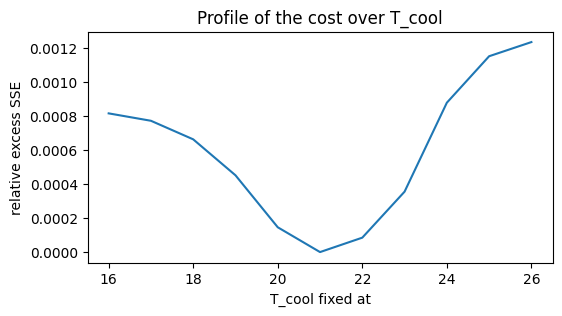

16.0    0.00082
17.0    0.00077
18.0    0.00066
19.0    0.00045
20.0    0.00015
21.0    0.00000
22.0    0.00008
23.0    0.00036
24.0    0.00088
25.0    0.00115
26.0    0.00123
dtype: float64

In [9]:
grid = np.arange(16, 27, 1.0)
prof_cost = []
for Tc in grid:
    r = optimize.minimize(lambda th: sse([th[0], Tc]), x0=[15], method="Nelder-Mead")
    prof_cost.append(r.fun)
prof_cost = np.array(prof_cost)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(grid, prof_cost / prof_cost.min() - 1)
ax.set_xlabel("T_cool fixed at"); ax.set_ylabel("relative excess SSE"); ax.set_title("Profile of the cost over T_cool")
plt.show()
pd.Series(prof_cost / prof_cost.min() - 1, index=grid).round(5)

Between 18 and 24 °C the cost changes by well under 0.1%. Any `T_cool` in that range is
"the answer". Report the range, not the point.

**Interview check:** "Your optimiser gave T_cool = 21.1 with a standard error of 0.3.
Do you believe that?" — No: the standard error comes from a local quadratic
approximation, and the profile shows the surface is flat, not quadratic.

## 6. Standard errors from the Jacobian, and why they are too small here

`least_squares` returns the Jacobian `J` at the solution. The usual covariance is
`σ² (JᵀJ)⁻¹` with `σ² = SSE / (n − p)`. `curve_fit`'s `pcov` is the same thing. It assumes
independent, equal-variance errors — hourly residuals are strongly autocorrelated, so the
effective sample size is far smaller than 17,520 and these standard errors are optimistic.

In [10]:
res_b = optimize.least_squares(residuals, x0=p0, bounds=(lb, ub), args=(T, y))
J = res_b.jac
n, p = J.shape
sigma2 = 2 * res_b.cost / (n - p)
cov = sigma2 * np.linalg.inv(J.T @ J)
se_jac = np.sqrt(np.diag(cov))

resid = residuals(res_b.x, T, y)
rho1 = np.corrcoef(resid[1:], resid[:-1])[0, 1]
n_eff = n * (1 - rho1) / (1 + rho1)               # AR(1) effective sample size

pd.DataFrame({"estimate": res_b.x, "se_iid": se_jac, "se_ar1_adjusted": se_jac * np.sqrt(n / n_eff)},
             index=["a", "b_heat", "c_cool", "T_heat", "T_cool"]).round(2).assign(
             note=["", "", "", "", "on bound: se meaningless"])

,estimate,se_iid,se_ar1_adjusted,note
a,-2136.64,18.42,67.01,
b_heat,360.44,1.70,6.19,
c_cool,113.93,10.98,39.94,
T_heat,14.85,0.07,0.25,
T_cool,18.00,0.33,1.19,on bound: se meaningless


In [11]:
print(f"lag-1 autocorrelation of residuals: {rho1:.3f}")
print(f"n = {n}, effective n ≈ {n_eff:,.0f}  →  se inflate by ×{np.sqrt(n/n_eff):.1f}")

lag-1 autocorrelation of residuals: 0.859
n = 17520, effective n ≈ 1,324  →  se inflate by ×3.6


**Pitfall:** `pcov` from `curve_fit` is only as good as its iid assumption. With hourly
data, either adjust (as above, roughly), use a block bootstrap, or fit on daily averages.

## 7. Robust losses when spikes are present

Least squares is dominated by outliers. `least_squares(loss="soft_l1" | "huber" | "cauchy",
f_scale=...)` down-weights residuals larger than `f_scale`. Demonstrate by injecting spikes.

In [12]:
rng = np.random.default_rng(42)
y_spiky = y.copy()
spike_idx = rng.choice(len(y), 150, replace=False)
y_spiky[spike_idx] += rng.uniform(15_000, 30_000, 150)       # 150 huge positive outliers

rows = []
for loss, fs in [("linear", 1.0), ("soft_l1", 1000), ("huber", 1000), ("cauchy", 1000)]:
    r = optimize.least_squares(residuals, x0=p0, bounds=(lb, ub), args=(T, y_spiky), loss=loss, f_scale=fs)
    rows.append([loss, *r.x.round(1)])
clean = optimize.least_squares(residuals, x0=p0, bounds=(lb, ub), args=(T, y)).x.round(1)
rows.append(["(clean data, linear)", *clean])
pd.DataFrame(rows, columns=["loss", "a", "b_heat", "c_cool", "T_heat", "T_cool"])

,loss,a,b_heat,c_cool,T_heat,T_cool
0,linear,-1895.4,360.4,92.5,14.7,18.0
1,soft_l1,-2118.1,359.1,116.0,14.9,18.0
2,huber,-2121.7,359.1,116.6,14.9,18.0
3,cauchy,-2133.0,358.4,121.8,14.9,18.0
4,"(clean data, linear)",-2136.6,360.4,113.9,14.8,18.0


The plain least-squares level `a` and slopes move visibly with 150 spikes in 17,520 rows;
the robust losses stay close to the clean-data fit. `f_scale` is in the units of the
residual (MWh here) — set it to a "typical" residual size, not 1.

**Interview check:** "Why not just drop the outliers?" — Because you need a rule for what
an outlier is, and that rule is itself a model. A robust loss makes the rule explicit and
keeps the rows.

## 8. A supply curve: exponential vs linear, and inverting it

Price against residual load (demand minus wind and solar) is the merit-order curve.
A common parametric form is `price = α + β·exp(γ·x)`. Fit it, then ask which residual
load pushes the price above 200 €/MWh using a root finder.

In [13]:
df["residual_load"] = df["consumption_mwh"] - 900 * df["wind_ms"] - 12 * df["solar_wm2"]
d23 = df[df.year == 2023]
x = d23["residual_load"].values
price = d23["price_eur_mwh"].values

def supply_exp(x, alpha, beta, gamma):
    z = (x - 25_000) / 5_000                     # scaled input: see section 11 for why
    return alpha + beta * np.exp(gamma * z)

def supply_lin(x, a, b):
    return a + b * (x - 25_000) / 5_000

p_exp, _ = optimize.curve_fit(supply_exp, x, price, p0=[50, 20, 0.5], maxfev=20_000)
p_lin, _ = optimize.curve_fit(supply_lin, x, price, p0=[100, 20])

rmse = lambda f, p: np.sqrt(np.mean((f(x, *p) - price) ** 2))
print("exp params (alpha, beta, gamma):", p_exp.round(3), " rmse:", rmse(supply_exp, p_exp).round(2))
print("lin params (a, b):             ", p_lin.round(3), " rmse:", rmse(supply_lin, p_lin).round(2))

exp params (alpha, beta, gamma): [-18781.566  18887.267      0.002]  rmse: 16.25
lin params (a, b):              [105.715  31.804]  rmse: 16.25


`γ ≈ 0.002` with `β ≈ −α ≈ 20,000`: the exponential has flattened itself into a straight
line (`β·e^{γz} ≈ β + βγz`). The extra parameter buys nothing; the linear fit is equally
good. **Pitfall:** a "convex supply curve" is a prior, not a finding — this data shows no
convexity, and the exponential form would extrapolate wildly if you believed `γ` anyway.

Invert the (linear) curve with `brentq`: find `x` such that `price(x) − 200 = 0`. `brentq`
needs a bracket where the function changes sign.

In [14]:
target = 200.0
f = lambda x_: supply_lin(x_, *p_lin) - target
lo_, hi_ = 10_000, 80_000
print("f(lo), f(hi):", f(lo_).round(1), f(hi_).round(1), "(must have opposite signs)")
x_star = optimize.brentq(f, lo_, hi_)
print(f"residual load for an expected price of {target:.0f} €/MWh: {x_star:,.0f} MWh")
print(f"share of 2023 hours above that: {(x > x_star).mean():.2%}   (max observed: {x.max():,.0f})")

f(lo), f(hi): -189.7 255.6 (must have opposite signs)
residual load for an expected price of 200 €/MWh: 39,823 MWh
share of 2023 hours above that: 0.00%   (max observed: 38,447)


The answer lies beyond the largest residual load observed in 2023, so it is an
extrapolation of the fitted line, not something the data has seen. Say so when you report it.

## 9. A daily load shape as two Gaussians

Sometimes you want a smooth parametric daily profile (e.g. to scale a customer's annual
consumption into hours). Fit the average hour-of-day profile as a baseline plus a morning
and an evening Gaussian bump.

params: {'base': 24005.0, 'm1': 9.6, 's1': 2.6, 'A1': 8457.0, 'm2': 18.1, 's2': 2.8, 'A2': 10714.6}
rmse: 580.0 MWh  (profile range 23610.0 - 35363.0 )


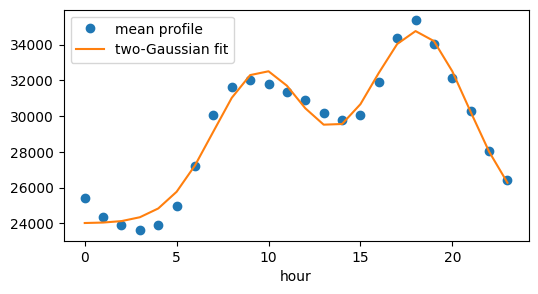

In [15]:
prof24 = df.groupby("hour")["consumption_mwh"].mean().values
h = np.arange(24)

def two_gauss(h, base, m1, s1, A1, m2, s2, A2):
    return (base + A1 * np.exp(-0.5 * ((h - m1) / s1) ** 2)
                 + A2 * np.exp(-0.5 * ((h - m2) / s2) ** 2))

pg, _ = optimize.curve_fit(two_gauss, h, prof24, p0=[22_000, 10, 3, 6_000, 18, 2, 6_000], maxfev=20_000)
fit24 = two_gauss(h, *pg)
print("params:", dict(zip(["base", "m1", "s1", "A1", "m2", "s2", "A2"], pg.round(1))))
print("rmse:", np.sqrt(np.mean((fit24 - prof24) ** 2)).round(0), "MWh  (profile range",
      prof24.min().round(0), "-", prof24.max().round(0), ")")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(h, prof24, "o", label="mean profile"); ax.plot(h, fit24, label="two-Gaussian fit")
ax.set_xlabel("hour"); ax.legend(); plt.show()

**Interview check:** "Why two Gaussians and not a 24-value lookup table?" — The lookup
table fits perfectly and has 24 parameters; the Gaussians have 7 and give you *named*
quantities (peak hour, peak width) you can compare across customer groups. Neither is
"right"; know what you are buying.

## 10. Maximum likelihood with `minimize`

When the objective is not a sum of squares, use `minimize`. Example: an AR(1) model on
hour-demeaned consumption, `r_t − μ = φ (r_{t−1} − μ) + ε_t`, `ε ~ N(0, σ²)`.
Negative log-likelihood, gradient-free (Nelder-Mead) vs quasi-Newton (L-BFGS-B).
Parameterise `σ` as `exp(log σ)` so the optimiser cannot make it negative.

In [16]:
r_ = (df["consumption_mwh"] - df.groupby("hour")["consumption_mwh"].transform("mean")).values

def nll(theta, r):
    mu, phi, log_sigma = theta
    sigma = np.exp(log_sigma)
    e = r[1:] - mu - phi * (r[:-1] - mu)
    return 0.5 * len(e) * np.log(2 * np.pi * sigma ** 2) + 0.5 * (e @ e) / sigma ** 2

x0 = [0.0, 0.5, np.log(1000)]
res_nm = optimize.minimize(nll, x0, args=(r_,), method="Nelder-Mead")
res_lb = optimize.minimize(nll, x0, args=(r_,), method="L-BFGS-B")
phi_ols = np.corrcoef(r_[1:], r_[:-1])[0, 1]

pd.DataFrame({
    "Nelder-Mead": [*res_nm.x, np.exp(res_nm.x[2]), res_nm.fun, res_nm.nfev, res_nm.success],
    "L-BFGS-B":    [*res_lb.x, np.exp(res_lb.x[2]), res_lb.fun, res_lb.nfev, res_lb.success],
}, index=["mu", "phi", "log_sigma", "sigma", "nll", "nfev", "success"]).T.round(4).assign(phi_ols_closed_form=round(phi_ols, 4))

,mu,phi,log_sigma,sigma,nll,nfev,success,phi_ols_closed_form
Nelder-Mead,-0.003674,0.970664,6.340166,566.89026,135931.656901,104,True,0.9707
L-BFGS-B,0.0,0.970661,6.340161,566.88784,135931.656899,48,True,0.9707


Both methods agree with the closed-form OLS `φ`. L-BFGS-B needed far fewer function
evaluations because it uses (finite-difference) gradients; Nelder-Mead is slower but does
not care about smoothness.

**Pitfall:** always print `res.success` and `res.message`. `minimize` returns an
`OptimizeResult` even when it failed; `res.x` is then whatever it stopped at.

In [17]:
# what a failure looks like: an absurd starting point and a tight iteration budget
bad = optimize.minimize(nll, [50_000, 5.0, 20.0], args=(r_,), method="L-BFGS-B", options={"maxiter": 3})
print("success:", bad.success, "|", bad.message)
print("x:", bad.x.round(3), " nll:", f"{bad.fun:.3g}", " (good nll was", f"{res_lb.fun:.3g})")

success:

 False | STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
x: [50000.        0.913    10.125]  nll: 1.94e+05  (good nll was 1.36e+05)


## 11. Scaling: why optimisers fail when parameters differ by orders of magnitude

Gradient-based methods take steps of similar size in every direction. If one parameter
lives at 30,000 and another at 0.002, the step that is fine for the first is enormous for
the second (or vice versa). Two remedies: rescale inputs so parameters are O(1), or pass
`x_scale` to `least_squares`. Here is the supply-curve fit on **unscaled** residual load.

In [18]:
def supply_exp_raw(x, alpha, beta, gamma):
    return alpha + beta * np.exp(gamma * x)          # x is ~30,000 here

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                  # overflow warnings expected
    try:
        p_raw, _ = optimize.curve_fit(supply_exp_raw, x, price, p0=[50, 20, 0.5], maxfev=5_000)
        print("raw fit params:", p_raw)
    except Exception as e:
        print("curve_fit failed:", type(e).__name__, "-", str(e)[:90])

    # same model, gamma started at a sensible magnitude for x ~ 3e4: still fragile
    try:
        p_raw2, _ = optimize.curve_fit(supply_exp_raw, x, price, p0=[50, 20, 1e-4], maxfev=5_000)
        print("raw fit with tiny gamma start:", p_raw2, " rmse:", rmse(supply_exp_raw, p_raw2).round(2))
    except Exception as e:
        print("second attempt failed:", type(e).__name__, "-", str(e)[:90])

raw fit params: [50.  20.   0.5]


raw fit with tiny gamma start: [-16738.4809  16685.7266      0.    ]  rmse: 16.25


`exp(0.5 · 30,000)` overflows on the first evaluation, so every trial step produced
`inf`, and `curve_fit` handed back the starting values **unchanged without raising**. A
result identical to `p0` is a failure that looks like success. With `γ` started at `1e-4` it
works, but only because that start already avoids the overflow. The scaled version in
section 8 (`z = (x − 25,000)/5,000`) converged from a generic start.
Rule: **before fitting, put every input and every parameter roughly in [−10, 10]**.

In [19]:
# x_scale: tell least_squares the natural size of each parameter
def sup_res(theta, x, price):
    return supply_exp_raw(x, *theta) - price

for xs in [None, "jac", np.array([100, 100, 1e-4])]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            r = optimize.least_squares(sup_res, x0=[50, 20, 1e-4], args=(x, price),
                                       x_scale=(1.0 if xs is None else xs), max_nfev=2000)
            print(f"x_scale={str(xs):22s} status={r.status} cost={r.cost:.4g} x={r.x}")
        except Exception as e:
            print(f"x_scale={str(xs):22s} failed: {type(e).__name__}")

x_scale=None                   status=2 cost=1.156e+06 x=[-15975.016   15922.2877      0.    ]


x_scale=jac                    status=2 cost=1.156e+06 x=[-15974.5895  15921.8612      0.    ]


x_scale=[100.     100.       0.0001] status=2 cost=1.156e+06 x=[-18217.5838  18164.785       0.    ]


With a sane starting point all three `x_scale` variants converge to the same (linear)
solution. `x_scale` is insurance for badly scaled *parameters*; it does not rescue a model
that overflows for badly scaled *inputs*.

## 12. In-sample fit, out-of-sample check

Calibrate the heating/cooling model on 2022, predict 2023. The trend term is the one to
watch: a linear trend fitted on one year extrapolates, and there is no guarantee it holds.

In [20]:
def fit_vp(mask):
    Hm, wkm, tm, Tm, ym = H[mask], wk[mask], t[mask], T[mask], y_full[mask]
    def design_m(Th, Tc):
        return np.column_stack([Hm, wkm, tm, np.clip(Th - Tm, 0, None), np.clip(Tm - Tc, 0, None)])
    def sse_m(bp):
        X = design_m(*bp); b, *_ = np.linalg.lstsq(X, ym, rcond=None); r = ym - X @ b; return r @ r
    bp = optimize.minimize(sse_m, x0=[14, 21], method="Nelder-Mead", options={"xatol": 1e-2, "fatol": 10}).x
    X = design_m(*bp); b, *_ = np.linalg.lstsq(X, ym, rcond=None)
    return bp, b

def predict_vp(bp, b, mask):
    X = np.column_stack([H[mask], wk[mask], t[mask], np.clip(bp[0] - T[mask], 0, None), np.clip(T[mask] - bp[1], 0, None)])
    return X @ b

m22 = (df.year == 2022).values
m23 = ~m22
bp22, b22 = fit_vp(m22)
pred22 = predict_vp(bp22, b22, m22)
pred23 = predict_vp(bp22, b22, m23)

def metrics(yt, yp):
    e = yt - yp
    return pd.Series({"rmse": np.sqrt(np.mean(e**2)), "mae": np.mean(np.abs(e)), "bias": e.mean(), "r2": 1 - (e@e)/((yt-yt.mean())@(yt-yt.mean()))})

pd.DataFrame({"in-sample 2022": metrics(y_full[m22], pred22), "out-of-sample 2023": metrics(y_full[m23], pred23)}).round(3)

,in-sample 2022,out-of-sample 2023
rmse,748.740,755.970
mae,598.425,603.315
bias,0.000,34.764
r2,0.969,0.967


In [21]:
# where does the 2023 error come from? bias by month tells you whether the trend extrapolation is the culprit
err23 = pd.Series(y_full[m23] - pred23, index=df.loc[m23, "time"])
err23.groupby(err23.index.month).mean().round(0).rename("mean error by month (2023)")

time
1     -59.0
2      55.0
3     113.0
4     120.0
5     -10.0
6    -112.0
7      28.0
8     107.0
9      84.0
10    175.0
11     27.0
12   -109.0
Name: mean error by month (2023), dtype: float64

Here the two are almost identical and the monthly bias has no drift: the trend held over
2023 (in this synthetic data). Real demand trends do break — that is what this check is for.

**Interview check:** "The 2023 RMSE is higher than 2022. Is the model broken?" — Some
deterioration is normal (parameters were tuned to 2022's noise). Look at the *bias by
month*: a steadily drifting sign means the trend term is extrapolating wrongly; a flat
bias with fatter tails means the model is fine and 2023 was just noisier.

## Quick reference

| Task | Tool | Watch out |
|---|---|---|
| Fit `y = f(x, θ)` | `curve_fit(f, x, y, p0, bounds)` | always pass `p0`; `pcov` assumes iid errors |
| Same, more control | `least_squares(res_fn, x0, bounds, loss, x_scale)` | check `status`/`message`; params on a bound |
| Any scalar objective | `minimize(fun, x0, method=...)` | check `success`; `x` is returned even on failure |
| Linear-in-some-params | variable projection: `lstsq` inside, `minimize` outside | fewer non-linear params, far more stable |
| Is a parameter identified? | profile the cost over a grid | flat profile ⇒ report a range |
| Outliers | `loss="soft_l1" / "huber"`, `f_scale` in residual units | still inspect what got down-weighted |
| Root / inversion | `brentq(f, a, b)` | bracket must change sign |
| Standard errors | `σ²(JᵀJ)⁻¹`, inflate for autocorrelation | or block bootstrap |
| Scaling | inputs and params O(1); `x_scale` | `exp(large)` overflows silently |
| Validation | fit one year, test the next; bias by month | trend terms extrapolate |